In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from torch import nn
import torch.nn.functional as F
from scipy.stats import linregress
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import json

In [2]:
def moving_average(data, window_size=15):
    X_smooth = np.zeros(data.shape)
    for i,channel in enumerate(data):
        X_smooth[i] = np.convolve(channel, np.ones(window_size)/window_size, mode='same')
    return torch.from_numpy(X_smooth).to(torch.float32)
def warp_time(data, label, max_scale=1.5):
    data = data.numpy()

    L = data.shape[1]
    scale = np.random.uniform(1, max_scale)
    new_L = int(L * scale)
    orig_t = np.linspace(0, 1, L)
    new_t = np.linspace(0, 1, new_L)

    warped = np.zeros((data.shape[0], new_L))
    for i, channel in enumerate(data):
        warped[i] = np.interp(new_t, orig_t, channel)
    
    # label = torch.from_numpy(np.interp(new_t, orig_t, label)).to(torch.float32)
    # label = label * scale

    # randomly crop to original length
    if new_L > L:
        start_idx = np.random.randint(0, new_L - L)
        warped = warped[:, start_idx:start_idx + L]
        # label = label[start_idx:start_idx + L]
        # label = label - (start_idx / L)

    return torch.from_numpy(warped).to(torch.float32), label

def scale(data, low=0.6, high=1.4):
    return data*np.random.uniform(low, high)

def segment_y(y, t=40):
    end_rep_markers = torch.where(torch.diff(y) < 0)[0]
    y = torch.zeros_like(y)
    starts = (end_rep_markers - t).clamp(0)
    ends = (end_rep_markers + t).clamp(0, y.shape[0])
    for start,end in zip(starts, ends):
        y[start: end] = 1
    return y
class IMUDataset(Dataset):
    def __init__(self, df, winsize, stride, full_winsize, n_LSTM_windows, LSTM_stride, transform=None, aug=False):
        self.X = torch.from_numpy(df[['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values)
        self.y = torch.from_numpy(df['rir'].values).to(torch.float32)
        if transform is not None:
            self.X = transform(self.X)
        self.X = self.X.transpose(0, 1).to(torch.float32)
        self.winsize = winsize
        self.stride = stride
        self.full_winsize = full_winsize
        self.n_LSTM_windows = n_LSTM_windows
        self.LSTM_stride = LSTM_stride
        self.aug = aug
        
        self.len = (self.X.shape[1] - full_winsize) // stride + 1

        # pad to get at least one window
        if self.len <= 0:
            pad = full_winsize - self.X.shape[1]
            self.X = torch.cat([self.X, torch.zeros(self.X.shape[0], pad)], dim=1)
            self.y = torch.cat([self.y, torch.zeros(pad)])

        # pad by winsize // 2 to get more windows
        pad = (winsize // 2) * stride
        self.X = torch.cat([self.X, torch.zeros(self.X.shape[0], pad)], dim=1)
        self.y = torch.cat([self.y, torch.zeros(pad)])
        self.len = (self.X.shape[1] - full_winsize) // stride + 1

    def __len__(self):
        return self.len
    def __getitem__(self, i):
        if i >= self.len:
            raise IndexError
        start = i * self.stride
        end = start + self.full_winsize

        X = self.X[:, start:end]
        y = self.y[start:end]

        X = moving_average(X)
        if self.aug:
            X,y = warp_time(X,y)
            X = scale(X)
        
        # window by LSTM stride
        X = X.unfold(1, self.winsize, self.LSTM_stride).permute(1,0,2)
        y = y.unfold(0, self.winsize, self.LSTM_stride)

        # FOR REGRESSION: y = y.mean() (single value)
        y = y.mean(dim=1).unsqueeze(1) / 13 # assume at most 13 rir

        # FOR BINARY: 1 if y is last rep (< 1.5), 0 if not (single value)
        # y = torch.Tensor([1.0 if y.mean() < 1.5 else 0.0])
        # y = (y.mean(dim=1) < 0.5).float().unsqueeze(1)

        # FOR SEGMENTATION: if y changes during window, y = 1 at that point. everywhere else is 0 (<winsize> values)
        # y = segment_y(y)

        # FOR SEGMENTATION REGRESSION: y = time when y changes (single value)
        # diff = torch.diff(y)
        # y = torch.diff(y).argmin().unsqueeze(0) / self.winsize if diff.min() < 0 else torch.Tensor([-1])
        
        return X, y

In [3]:
HZ = 100
in_channels = 6
df = pd.read_csv('../data/data.csv')
session_ids = df['session_id'].unique()
print(len(session_ids))
train_ids, val_ids = train_test_split(session_ids, test_size=0.2, random_state=42)
train_ids = np.array([train_id for train_id in train_ids if df[df.session_id == train_id].failure.sum()])
val_ids = np.array([val_id for val_id in val_ids if df[df.session_id == val_id].failure.sum()])

df[['acc_x', 'acc_y', 'acc_z']] = (df[['acc_x', 'acc_y', 'acc_z']] / 2.0).clip(-1, 1)           # normalize accelerometer data from [-2g, 2g] to [-1, 1]
df[['gyr_x', 'gyr_y', 'gyr_z']] = (df[['gyr_x', 'gyr_y', 'gyr_z']] / 250.0).clip(-1, 1)         # normalize gyroscope data from [-250dps, 250dps] to [-1, 1]

# winsize_t = 5 # seconds
# stride_t = 0.01 # seconds
# winsize = int(winsize_t * HZ)
# stride = int(stride_t * HZ)
winsize = 256
stride = 2

n_LSTM_windows = 16
LSTM_stride = 64
print(winsize, stride)

full_winsize = LSTM_stride * (n_LSTM_windows-1) + winsize

train = df.loc[df['session_id'].isin(train_ids), ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values
# norm = torch.from_numpy(train.mean(axis=0)), torch.from_numpy(train.std(axis=0))

# def transform(x):
    # return (x - norm[0]) / norm[1]
transform = None

train_dataset = ConcatDataset([IMUDataset(
    df[df['session_id'] == session_id], 
    winsize, stride,
    full_winsize, n_LSTM_windows, LSTM_stride,
    transform, aug=True
) for session_id in train_ids])
val_dataset = ConcatDataset([IMUDataset(
    df[df['session_id'] == session_id], 
    winsize, stride, 
    full_winsize, n_LSTM_windows, LSTM_stride,
    transform, aug=False
) for session_id in val_ids])

len(train_dataset), len(val_dataset)

72
256 2


(69335, 19539)

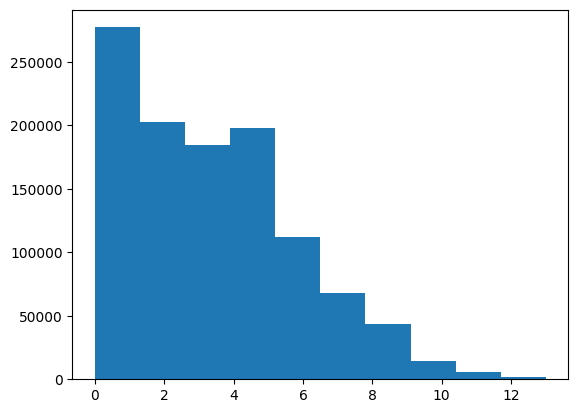

In [4]:
windows = []
window_labels = []
for X, y in train_dataset:
    # windows.append(X.T.numpy())
    window_labels.append(y)
window_labels = np.concatenate(window_labels)
plt.hist(window_labels * 13);

tensor([0.2954, 0.2761, 0.2569, 0.2356, 0.2094, 0.1902, 0.1710, 0.1481, 0.1289,
        0.1097, 0.0904, 0.0709, 0.0517, 0.0325, 0.0132, 0.0000])


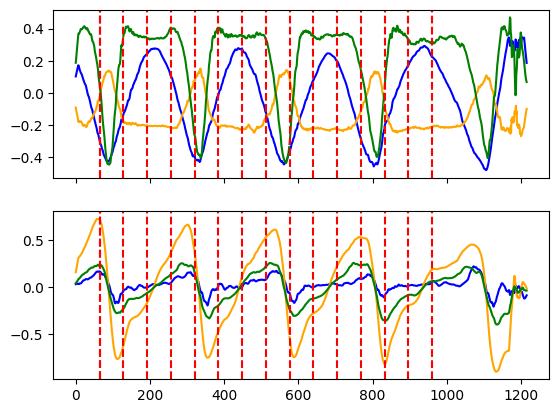

In [ ]:
# X,y = train_dataset[500]
X,y = val_dataset[440]

fig, axes = plt.subplots(2,1, sharex=True)

axes[0].plot(X[0, 0, :LSTM_stride], color='blue')
axes[0].plot(X[0, 1, :LSTM_stride], color='orange')
axes[0].plot(X[0, 2, :LSTM_stride], color='green')
axes[1].plot(X[0, 3, :LSTM_stride], color='blue')
axes[1].plot(X[0, 4, :LSTM_stride], color='orange')
axes[1].plot(X[0, 5, :LSTM_stride], color='green')
axes[0].axvline(LSTM_stride, color='red', linestyle='--')
axes[1].axvline(LSTM_stride, color='red', linestyle='--')

for i in range(1, n_LSTM_windows):
    upper = LSTM_stride if i < n_LSTM_windows - 1 else None
    range_upper = (i+1)*LSTM_stride if upper is not None else i*LSTM_stride + winsize
    axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 0, :upper], color='blue')
    axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 1, :upper], color='orange')
    axes[0].plot(np.arange(i*LSTM_stride, range_upper), X[i, 2, :upper], color='green')
    axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 3, :upper], color='blue')
    axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 4, :upper], color='orange')
    axes[1].plot(np.arange(i*LSTM_stride, range_upper), X[i, 5, :upper], color='green')
    axes[0].axvline(i*LSTM_stride, color='red', linestyle='--')
    axes[1].axvline(i*LSTM_stride, color='red', linestyle='--')

print(y[:,0])

In [17]:
def get_time_in_reps(preds, stride, winsize):
    # preds: N x T x C
    time_in_rep = []
    # consolidated = []
    end_reps = []
    for pred in preds: # each element in batch
        consolidatedi = []
        for i,predi in enumerate(pred): # each element in time
            upper = stride if i < len(pred) - 1 else len(predi)
            consolidatedi.append(predi[:upper])
        consolidatedi = torch.cat(consolidatedi, axis=0)
        consolidatedi = torch.from_numpy(np.convolve(consolidatedi, np.ones(100)/100, mode='same').round()).to(torch.float32)

        time_in_repi = torch.zeros_like(consolidatedi).to(torch.float32)
        end_repsi = []
        if consolidatedi.sum() > 0:
            diff = np.diff(consolidatedi)
            starts = np.where(diff > 0)[0]
            ends = np.where(diff < 0)[0]
            if len(starts) == 0 or len(ends) == 0:
                if len(starts) == 0:
                    # len(end) == 1 -> start is the beginning of session
                    starts = np.array([0])
                elif len(ends) == 0:
                    # len(start) == 1 -> end is the end of session
                    ends = np.array([len(pred[0])])
            else:
                if starts[0] > ends[0]:
                    # first end has no start -> first start is the beginning of session
                    starts = np.concatenate([[0], starts])
                if ends[-1] < starts[-1]:
                    # last start has no end -> last end is the end of session
                    ends = np.concatenate([ends, [len(pred[0])]])
            for start,end in zip(starts, ends):
                end_repsi.append((start + end) // 2)
            
            for i in range(1, len(end_repsi)):
                time_in_repi[end_repsi[i-1]:end_repsi[i]] = (end_repsi[i] - end_repsi[i-1]) / full_winsize
                # time_in_rep.append(end_repsi[i] - end_repsi[i-1])

        end_reps.append(end_repsi)
        # consolidated.append(consolidatedi)
        time_in_rep.append(time_in_repi)
    # preds = torch.stack(consolidated, axis=0)
    time_in_rep = torch.stack(time_in_rep, axis=0)

    # rewindow
    time_in_rep = time_in_rep.unfold(1, winsize, stride)

    return time_in_rep

class ResBlock(nn.Module):
    # One layer of convolutional block with batchnorm, relu and dropout
    def __init__(
            self, in_channels, out_channels,
            kernel_size=3, stride=1, dropout=0.0,
        ):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(
                in_channels, out_channels, 
                kernel_size=kernel_size, stride=stride, padding=kernel_size // 2,
            ),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.skip = nn.Conv1d(
            in_channels, out_channels, kernel_size=1, stride=stride
        ) if in_channels != out_channels or stride > 1 else nn.Identity()
    def forward(self, x):
        return self.block(x) + self.skip(x)
    
class DepthBlock(nn.Module):
    # "depth" number of ConvBlocks with downsample on the first block
    def __init__(
            self, depth, in_channels, out_channels,
            kernel_size=3, downsample_stride=2, 
            dropout=0.0
    ):
        super().__init__()
        self.blocks = nn.Sequential(*[
            ResBlock(
                in_channels=in_channels if i == 0 else out_channels, 
                out_channels=out_channels,
                kernel_size=kernel_size, 
                stride=downsample_stride if i == 0 else 1,
                dropout=dropout
            )
            for i in range(depth)
        ])
    def forward(self, x):
        return self.blocks(x)
 
class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.width = config['width']
        self.depth = config['depth']
        self.stem_out_c = config['stem_out_c']
        self.stem_kernel = config['stem_kernel']
        self.dropout = config['dropout']

        if len(self.width) != len(self.depth):
            raise ValueError('Width and depth must have the same length')
        self.conv_out_channels = self.stem_out_c if len(self.width) == 0 else self.width[-1]

        self.encoder = nn.Sequential(
            # nn.Conv1d(in_channels, self.stem_out_c, kernel_size=self.stem_kernel, padding=self.stem_kernel // 2, stride=2),
            # nn.BatchNorm1d(self.stem_out_c),
            # nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),
            ResBlock(in_channels, self.stem_out_c, kernel_size=self.stem_kernel, stride=2),
            *[DepthBlock(
                depth=self.depth[i],
                in_channels=self.stem_out_c if i == 0 else self.width[i-1], 
                out_channels=self.width[i],
                dropout=self.dropout, 
            ) for i in range(len(self.width))]
        )
    def forward(self, x):
        return self.encoder(x)

class ConvNet(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        self.encoder = Encoder(config)
        self.ap = nn.AdaptiveAvgPool1d(1)
        # self.fc = nn.Linear(512, winsize // 2)
        self.fc = nn.Linear(self.encoder.conv_out_channels, winsize)
    def forward(self, x):
        emb = self.encoder(x)
        # x = self.conv(x)
        x = self.ap(emb).squeeze(-1)
        seg_logits = self.fc(x)
        # x = torch.repeat_interleave(x, 2, dim=1)
        return emb, seg_logits
    
    def freeze(self, stop_idx=None):
        if stop_idx is None:
            stop_idx = len(self.encoder.encoder)
        for block in self.encoder.encoder[:stop_idx]:
            for param in block.parameters():
                param.requires_grad = False
        for param in self.fc.parameters():
            param.requires_grad = False


class LSTMNet(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        in_channels = 6


        self.encoder = ConvNet(config)
        hidden_size = config['lstm_config']['hidden_size']
        # encoder_proj_channels = config['lstm_config']['encoder_proj_channels']
        skip_channels = config['lstm_config']['skip_channels']
        num_layers = config['lstm_config']['num_layers']
        dropout = config['lstm_config']['dropout']
        linear_hidden_size = config['lstm_config']['linear_hidden_size']

        # # Project encoder output to hidden size
        # self.conv_proj = nn.Conv1d(
        #     self.encoder.encoder.conv_out_channels, 
        #     encoder_proj_channels, 
        #     kernel_size=1
        # )

        # Convolution layer from input signal to skip_channels size
        self.conv_skip = nn.Sequential(
            nn.Conv1d(in_channels, skip_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(skip_channels),
            nn.ReLU(),
            # ResBlock(in_channels, skip_channels, kernel_size=7, stride=1),
        )
        self.ap = nn.AdaptiveAvgPool1d(1)

        # Project encoder, skip layer, and time_in_reps to lstm input size
        self.lstm_proj = nn.Linear(
            # encoder_proj_channels + skip_channels + winsize,
            self.encoder.encoder.conv_out_channels + skip_channels + winsize,
            hidden_size
        )

        # LSTM layer on projected encoder, skip layer, and time_in_reps
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
            num_layers=num_layers,
            dropout=dropout
        )
        self.lstm2 = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
            num_layers=4
        )

        # Linear layer to predict the output
        if linear_hidden_size == 0:
            self.reg = nn.Linear(hidden_size, 1)
        else:
            self.reg = nn.Sequential(
                nn.Linear(hidden_size, linear_hidden_size),
                nn.ReLU(),
                nn.Linear(linear_hidden_size, 1)
            )
    def forward(self, x):
        N, T, C, L = x.shape

        x = x.view(N*T, C, L)
        
        # Run encoder to get embeddings and segmentation logits
        x_seg, seg_logits = self.encoder(x)

        # x_seg = self.conv_proj(x_seg)
        x_seg = self.ap(x_seg).squeeze(-1)
        x_seg = x_seg.view(N, T, -1)

        # Project segmentation logits to seg_proj_size
        time_in_rep = get_time_in_reps(seg_logits.view(N, T, L).detach().cpu(), LSTM_stride, winsize).to(x.device)

        x_skip = self.conv_skip(x)
        x_skip = self.ap(x_skip).squeeze(-1)
        x_skip = x_skip.view(N, T, -1)

        x = torch.cat([x_seg, x_skip, time_in_rep], dim=2)
        x = self.lstm_proj(x)

        o, (h,c) = self.lstm(x)
        o, (h,c) = self.lstm2(o)

        # x = self.reg(o[:, -1, :]) # predict for last time step
        x = self.reg(o)        # predict for all time steps
        return x
    
    def get_optimizer(self, lr, weight_decay=1e-4, betas=(0.9, 0.999)):
        # AdamW optimzer - apply weight decay to linear and conv weights
        # but not to biases and batchnorm layers
        params = self.named_parameters()
        decay_params = [p for n,p in params if p.dim() >= 2]
        no_decay_params = [p for n,p in params if p.dim() < 2]
        optimizer = torch.optim.AdamW([
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': no_decay_params, 'weight_decay': 0.0}
        ], betas=betas, lr=lr)
        return optimizer

In [23]:
# config = json.load(open('../logs/search256-3/56/config.json'))
# weights = torch.load('../logs/search256-3/56/best_model.pth')
# weights, config = torch.load('../best_model-class-83_2.pth')
# config['lstm_config'] = lstm_config

weights, config = torch.load('../best_model-lstm-83t_32-timerep.pth')
config['lstm_config']['linear_hidden_size'] = 32

trainloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=128, shuffle=False)
device = 'cuda'

model = LSTMNet(config).to(device)
model.encoder.load_state_dict({'.'.join(k.split('.')[1:]):v for k,v in weights.items() if k.startswith('encoder.')})
model.conv_skip.load_state_dict({'.'.join(k.split('.')[1:]):v for k,v in weights.items() if k.startswith('conv_skip.')})
model.lstm_proj.load_state_dict({'.'.join(k.split('.')[1:]):v for k,v in weights.items() if k.startswith('lstm_proj.')})
model.lstm.load_state_dict({'.'.join(k.split('.')[1:]):v for k,v in weights.items() if k.startswith('lstm.')})
model.encoder.freeze()
for param in model.conv_skip.parameters():
    param.requires_grad = False
for param in model.lstm_proj.parameters():
    param.requires_grad = False
# for param in model.lstm.parameters():
#     param.requires_grad = False


criterion = nn.MSELoss(device, reduction='mean')
optimizer = model.get_optimizer(lr=3e-4, weight_decay=1e-4)

print(sum(p.numel() for p in model.encoder.parameters()))
print(sum(p.numel() for p in model.parameters() if p.requires_grad))
model.eval();

2971648
37822529


In [24]:
X,y = next(iter(trainloader))
ypred = model(X.to(device))
ypred.shape

torch.Size([128, 16, 1])

In [25]:
def train(epochs, model, trainloader, valloader, criterion, optimizer, outfile='best_model.pth'):
    train_losses = []
    val_losses = []
    best_val_r = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X, y in trainloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            ypred = model(X)
            loss = criterion(ypred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_losses.append(train_loss / len(trainloader))
        model.eval()
        val_loss = 0
        ypreds =[]
        ys = []
        with torch.no_grad():
            for X, y in valloader:
                X, y = X.to(device), y.to(device)
                ypred = model(X)
                loss = criterion(ypred, y)
                val_loss += loss.item()
                ypreds.append(ypred.cpu())
                ys.append(y.cpu())
        ypreds = torch.cat(ypreds, dim=0).flatten()
        ys = torch.cat(ys, dim=0).flatten()
        val_losses.append(val_loss / len(valloader))
        rvalue = linregress(ys.numpy(), ypreds.numpy())
        if rvalue.rvalue > best_val_r:
            best_val_r = rvalue.rvalue
            torch.save((model.state_dict(),model.config), outfile)
            print(f'*Epoch {epoch} train loss: {train_losses[-1]}, val loss: {val_losses[-1]}, R^2: {rvalue.rvalue**2}')
        else:
            print(f'Epoch {epoch} train loss: {train_losses[-1]}, val loss: {val_losses[-1]}, R^2: {rvalue.rvalue**2}')
        torch.save((model.state_dict(),model.config), f'model.pth')
        plt.plot(train_losses, label='Train')
        plt.plot(val_losses, label='Val')
        plt.legend()
        plt.savefig('loss.png')
        plt.close()
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.legend()
    plt.show()
    return train_losses, val_losses

In [26]:
def evaluate(model, valloader, trainloader):
    model.eval()
    # train_loss = 0
    # train_iou = 0
    # with torch.no_grad():
    #     for X, y in trainloader:
    #         X, y = X.to(device), y.to(device)
    #         ypred = model(X)
    #         loss = criterion(ypred, y)
    #         train_loss += loss.item()
    #         train_iou += iou_metric(F.sigmoid(ypred).round(), y).item()
    # train_loss /= len(trainloader)
    # train_iou /= len(trainloader)
    # print(f'Train Loss: {train_loss:.07f}\tTrain IOU: {train_iou:.07f}')

    val_loss = 0
    ypreds = []
    ys = []
    with torch.no_grad():
        for X, y in valloader:
            X, y = X.to(device), y.to(device)
            ypred = model(X)
            loss = criterion(ypred, y)
            val_loss += loss.item()
            ypreds.append(ypred.cpu())
            ys.append(y.cpu())

    ypreds = torch.cat(ypreds).numpy().flatten()
    ys = torch.cat(ys).numpy().flatten()

    val_loss /= len(valloader)
    print(f'Val Loss: {val_loss:.07f}')

    linreg = linregress(ys, ypreds)
    print(f'R^2: {linreg.rvalue**2:.07f}')

    fig, ax = plt.subplots()
    ax.plot(ys, ypreds, 'o', label='data')
    ax.plot(ys, linreg.intercept + linreg.slope*ys, 'r', label='fitted line')
    ax.legend()
    ax.set_xlabel('True RIR')
    ax.set_ylabel('Predicted RIR')
    ax.set_title(f'R^2: {linreg.rvalue**2:.07f}')
    plt.show()

*Epoch 0 train loss: 0.00864018777100115, val loss: 0.025071632590303136, R^2: 0.5150412325481867
Epoch 1 train loss: 0.0041591942789741, val loss: 0.02602395903071072, R^2: 0.48745335704352405
Epoch 2 train loss: 0.003457944544214357, val loss: 0.02548623180056441, R^2: 0.48351354034759336
Epoch 3 train loss: 0.0030258883609577355, val loss: 0.02598290317794582, R^2: 0.48791411805387486
Epoch 4 train loss: 0.002781974304015525, val loss: 0.02551497403818359, R^2: 0.4865467732720564
Epoch 5 train loss: 0.0025970940553322022, val loss: 0.02975629098364152, R^2: 0.4563542288437358
Epoch 6 train loss: 0.0024469430136109436, val loss: 0.026361682578187825, R^2: 0.4830687694921289
Epoch 7 train loss: 0.002276820203889079, val loss: 0.02658344898448977, R^2: 0.49034204012536864
Epoch 8 train loss: 0.0021599308180371883, val loss: 0.02521928666415168, R^2: 0.5039474920824848
Epoch 9 train loss: 0.002064163537998426, val loss: 0.026440774924137014, R^2: 0.5017615995506295


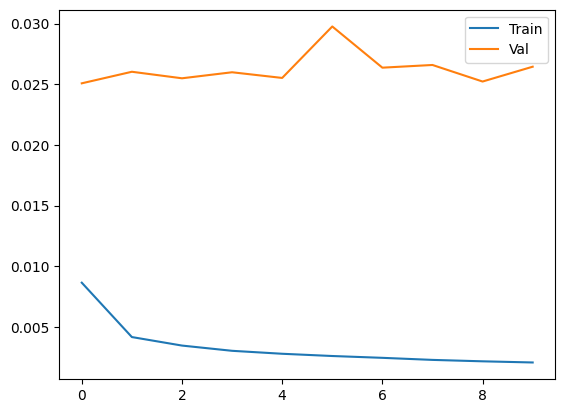

In [27]:
# TODO contrastive learning with RiR labels (positive pairs are failure reps)
train_losses, val_losses = train(10, model, trainloader, valloader, criterion, optimizer, outfile='../best_model-rir.pth')

Val Loss: 0.0250716
R^2: 0.5150412


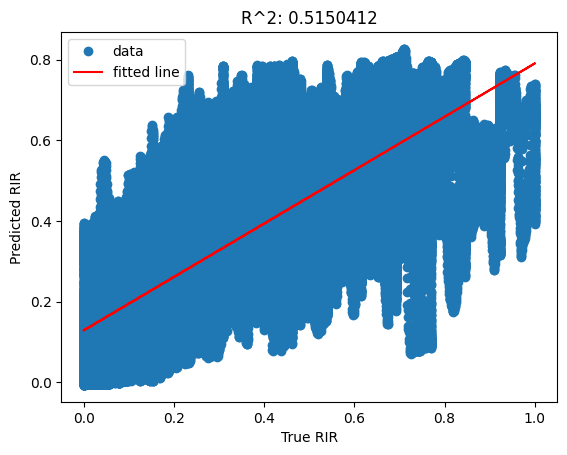

In [28]:
weights, config = torch.load('../best_model-rir.pth')
# config = json.load(open('../logs/search256/34/config.json'))
# weights = torch.load('../logs/search256/34/best_model.pth')
model = LSTMNet(config).to(device)
model.load_state_dict(weights)
evaluate(model, valloader, trainloader)

In [29]:
# full session
session_id = val_ids[5]
interval = 64

session = df[df['session_id'] == session_id]
session_dataset = IMUDataset(session, winsize, interval, full_winsize, n_LSTM_windows, LSTM_stride, transform=None, aug=False)
session.loc[:,['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']] = \
    moving_average(torch.from_numpy(session[['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values.T)).numpy().T

ys = []
ypreds = []

with torch.no_grad():
    # i = 0
    for i,(X,y) in enumerate(session_dataset):
        X = X.unsqueeze(0).to(device)
        ypred = model(X).cpu()
        ys.append(y[-1].cpu())
        ypreds.append(ypred[0])

ys = torch.cat(ys).numpy() * 13
ypreds = torch.cat(ypreds).numpy() * 13

ys = np.concat([
    np.zeros(full_winsize - winsize) - 1,
    np.repeat(ys, interval),
    np.zeros(session.shape[0] - ((len(session_dataset)-1) * interval + full_winsize) + winsize) - 1,
])
ypreds = np.concat([
    np.zeros(full_winsize - winsize) - 1,
    np.repeat(ypreds, interval),
    np.zeros(session.shape[0] - ((len(session_dataset)-1) * interval + full_winsize) + winsize) - 1,
])

fig, axes = plt.subplots(4,1, sharex=True, figsize=(15,10))
axes[0].plot(session['acc_x'].values, label='acc_x')
axes[0].plot(session['acc_y'].values, label='acc_y')
axes[0].plot(session['acc_z'].values, label='acc_z')

axes[1].plot(session['gyr_x'].values, label='gyr_x')
axes[1].plot(session['gyr_y'].values, label='gyr_y')
axes[1].plot(session['gyr_z'].values, label='gyr_z')

axes[2].plot(ys, label='true', linestyle='--', alpha=0.5)
axes[2].plot(ypreds, label='pred', linestyle='--', alpha=0.5)
axes[2].plot(ypreds.round(), label='rir_pred')

axes[2].plot(session['rir'].values, label='rir')

axes[0].legend(loc=(1.01, 0))
axes[1].legend(loc=(1.01, 0))
axes[2].legend(loc=(1.01, 0))
axes[3].legend(loc=(1.01, 0))

# for i in range(0, len(session), interval):
#     axes[2].axvline(i, color='red', linestyle='--')

ValueError: negative dimensions are not allowed

In [543]:
winsize // interval

4